# Project : Analyzing the trends of COVID-19 with Python

# STEP 1: Setup + Load Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/covid_19_clean_complete.csv")

In [4]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


##STEP 2: Data Cleaning & Preprocessing

In [6]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [9]:
df = df.drop(['Province/State', 'Lat', 'Long'], axis=1)

In [10]:
df = df.drop(['WHO Region'], axis=1)

In [11]:
df.columns

Index(['Country/Region', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

df_global = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

In [13]:
df_global.head()

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010


#**STEP** 3 : Visualization using Plotly

In [15]:
import plotly.express as px

#COVID-19 Confirmed Cases Over Time

In [16]:
fig = px.line(
    df_global,
    x='Date',
    y='Confirmed',
    title='COVID-19 Confirmed Cases Over Time'
)

fig.show()

#Death Cases

In [17]:
fig = px.line(
    df_global,
    x='Date',
    y='Deaths',
    title='COVID-19 Death Cases',
    color_discrete_sequence=['red']
)

fig.show()

#Recovered Cases

In [18]:
fig = px.line(
    df_global,
    x='Date',
    y='Recovered',
    title='COVID-19 Recovered Cases',
    color_discrete_sequence=['green']
)

fig.show()

In [19]:
fig = px.line(
    df_global,
    x='Date',
    y=['Confirmed', 'Deaths', 'Recovered', 'Active'],
    title='COVID-19 Global Trend Analysis'
)

fig.show()

The analysis shows an exponential rise in confirmed COVID-19 cases, with a significant surge after March 2020. While deaths increased steadily, recovery rates also improved over time, reducing the gap between active and recovered cases. The trend highlights the rapid spread of the virus and the growing pressure on healthcare systems during peak periods.

# STEP 4: Prepare Data for Prophet

In [21]:
from prophet import Prophet

In [22]:
df_prophet = df_global[['Date', 'Confirmed']]

In [23]:
df_prophet = df_prophet.rename(columns={
    'Date': 'ds',
    'Confirmed': 'y'
})

In [24]:
df_prophet.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [25]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      188 non-null    datetime64[ns]
 1   y       188 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.1 KB


In [26]:
df_prophet.isnull().sum()

,0
ds,0
y,0


In [27]:
df_prophet.tail()

,ds,y
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


# Model Prophet

In [28]:
model = Prophet()

In [29]:
model.fit(df_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [30]:
future = model.make_future_dataframe(periods=7)

In [31]:
forecast = model.predict(future)

In [32]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
190,2020-07-30,1.674392e+07,1.663612e+07,1.684820e+07
191,2020-07-31,1.695911e+07,1.685178e+07,1.707756e+07
192,2020-08-01,1.716677e+07,1.704666e+07,1.727097e+07
193,2020-08-02,1.736430e+07,1.725141e+07,1.747611e+07
194,2020-08-03,1.755889e+07,1.743522e+07,1.767690e+07


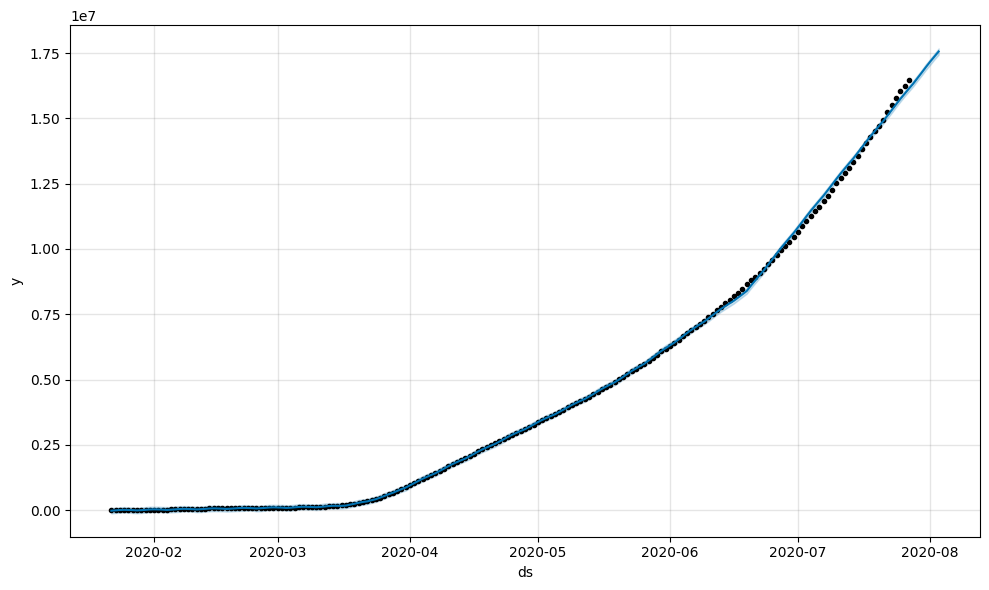

In [33]:
fig = model.plot(forecast)

In [34]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'],
                         mode='lines', name='Predicted'))

fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'],
                         mode='lines', name='Upper Bound', line=dict(dash='dot')))

fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'],
                         mode='lines', name='Lower Bound', line=dict(dash='dot')))

fig.update_layout(title='COVID-19 Forecast (Next 7 Days)',
                  xaxis_title='Date',
                  yaxis_title='Cases')

fig.show()

# Final Detailed Analysis: COVID-19 Trend & Forecast

#Introduction

This project analyzes the global spread of COVID-19 using time-series data and visualizes key trends such as confirmed, deaths, recovered, and active cases. Additionally, a forecasting model is built using Facebook Prophet to predict future case counts based on historical data.

#Data Understanding & Preprocessing

The dataset consisted of daily COVID-19 statistics across multiple countries. The data was cleaned by:

Removing irrelevant columns such as latitude, longitude, and province/state
Handling missing values
Converting the date column into datetime format
Aggregating data to obtain global daily totals

This preprocessing step ensured a structured time-series dataset suitable for analysis and forecasting.

#Exploratory Data Analysis (EDA)



1. Growth of Confirmed Cases

The confirmed cases show a rapid exponential increase, especially after March 2020. This indicates the transition from localized outbreaks to a global pandemic.

2. Death Trends

The number of deaths increases steadily over time but at a slower rate compared to confirmed cases, suggesting a relatively lower fatality ratio.

3. Recovery Trends

Recovered cases show a delayed but significant rise, indicating improvements in healthcare response and treatment over time.

4. Active Cases

Active cases increase sharply during the peak months, highlighting the burden on healthcare systems globally.

#Combined Trend Analysis

The combined visualization reveals:

A widening gap between confirmed and recovered cases initially
Gradual improvement in recovery rates over time
Persistent rise in active cases during peak periods

This indicates that while recovery improved, the infection spread outpaced recovery during early phases.

#Time Series Forecasting (Prophet Model)

A Prophet model was used to forecast future confirmed cases.

Model Preparation:
Renamed columns to Prophet format (ds, y)
Trained model on historical data
Generated future predictions for the next 7 days

#Forecast Insights

1. Future Trend

The forecast shows a continuous upward trajectory in confirmed cases, indicating ongoing spread.

2. Growth Behavior

The model captures an accelerating growth pattern, with increasing slope over time.

3. Model Performance

The predicted values closely align with actual data, demonstrating that the model effectively captures the trend.

4. Confidence Interval

The narrow confidence intervals indicate high reliability of short-term predictions.

#Key Findings

* COVID-19 cases exhibited exponential growth, particularly after March 2020.
* Death rates increased steadily but were lower relative to confirmed cases.
* Recovery rates improved over time, reducing active cases gradually.
* The pandemic placed significant pressure on healthcare systems during peak periods.
* Forecasting indicates no immediate decline, suggesting continued spread.



#Conclusion

This analysis highlights the rapid spread and impact of COVID-19 globally. The use of time-series forecasting provides valuable insights into future trends, enabling better planning and response strategies. While the model performs well for short-term predictions, long-term forecasts may require additional factors such as policy changes and vaccination data.